## Evaluation pipeline for the microlane experiment

In [5]:
# Imports of the Core Packages
import json, sys, time, pytz
import os, yaml,random 
import numpy as np
from datetime import datetime
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
# Import custom libraries located at different folder location + configs
from microlane.utils.metrics import *
from microlane.datasets.tusimple import TuSimple
from microlane.models.lanenet2.model import LaneNet2
from microlane.models.ufld.model import UFLD
from microlane.schema.output import ModelPrediction
from microlane.schema.sample import Sample
from microlane.utils.load_image import load_image_from_sample
from microlane.utils.experiment import ExperimentEvaluate
from microlane.utils.raw_image_to_sample import imageToSample

In [7]:
# First Load the Configuation file
with open("../configs/config.yaml", "r") as file:
    config = yaml.safe_load(file)

### Pre Processing Part

In [8]:

model = UFLD(
    
    container_folder=config['models']['ultra_fast_lane_detection']['container_folder'],
    
    image_name=config['models']['ultra_fast_lane_detection']['image_name']
)

Initializing container on port  8000
/home/suyog/desktop/projects/microlane/microlane/microlane/models/ufld/ufld
Image 'ufld_image:latest' already exists, skipping build.
Starting new container from 'ufld_image:latest' on port 8000...
Container started: ffc63557c904
Waiting for container to be ready on port 8000...
Container is ready.


In [9]:
experiment = ExperimentEvaluate(
    
    experiment_name="pipeline testing with no augmentation"
    
)

In [10]:
IMAGE_PATH = "/mnt/c/Users/suyog/Downloads/frame_0000.jpg"

item = imageToSample(IMAGE_PATH)

### Models and Datasets Loaded, Now Processing Part

### Adding Image Augmentation

In [11]:
blur_range = tuple(config['data']['augmentation']['blur'])
rotation_range = tuple(config['data']['augmentation']['blur'])
zoom_range = tuple(config['data']['augmentation']['zoom'])
lighting_range =tuple(config['data']['augmentation']['lighting'])
motion_blur_range=tuple(config['data']['augmentation']['motion_blur'])

In [12]:
# item.blur       = round(random.uniform(blur_range[0],       blur_range[1] - 0.01), 2)
# item.rotation   = round(random.uniform(rotation_range[0],   rotation_range[1] - 0.01), 2)
# item.zoom       = round(random.uniform(zoom_range[0],       zoom_range[1] - 0.01), 2)
# item.rotation   = round(random.uniform(rotation_range[0],   rotation_range[1] - 0.01), 2)
# item.lighting = round(random.uniform(lighting_range[0], lighting_range[1] - 0.01), 2)
# item.motion_blur = round(random.uniform(motion_blur_range[0], motion_blur_range[1] - 0.01), 2)


print(f"Blur:       {item.blur:.2f}")
print(f"Rotation:   {item.rotation:.2f}")
print(f"Zoom:       {item.zoom:.2f}")
print(f"lighting: {item.lighting:.2f}")
print(f"motion_blur:     {item.motion_blur:.2f}")

Blur:       0.00
Rotation:   0.00
Zoom:       1.00
lighting: 1.00
motion_blur:     0.00


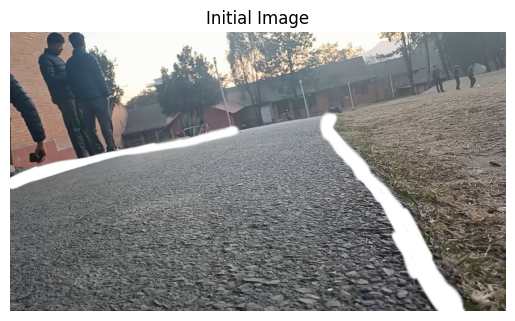

In [13]:
if item.image is not None:
    plt.imshow(item.image)
    plt.axis("off")
    plt.title("Initial Image")
    plt.show()

In [14]:
# We are basically sending a loaded sample with actual image tensor in the memory

response = model.predict(item)

In [16]:
prediction = response.json()

ModelOutput = ModelPrediction (
    
    sample=Sample(
            image=prediction['sample']['image'],
            image_path=prediction['sample']['image_path'],
            h_samples=prediction['sample']['h_samples'],
            lanes=prediction['sample']['lanes'],
            blur=prediction['sample']['blur'],
            lighting=prediction['sample']['lighting'],
            zoom=prediction['sample']['zoom'],
            rotation=prediction['sample']['rotation']
        ),
    
    lanes=prediction['lanes'],
        
    run_time=prediction['run_time']
    
)

In [17]:

experiment.store_prediction(ModelOutput)

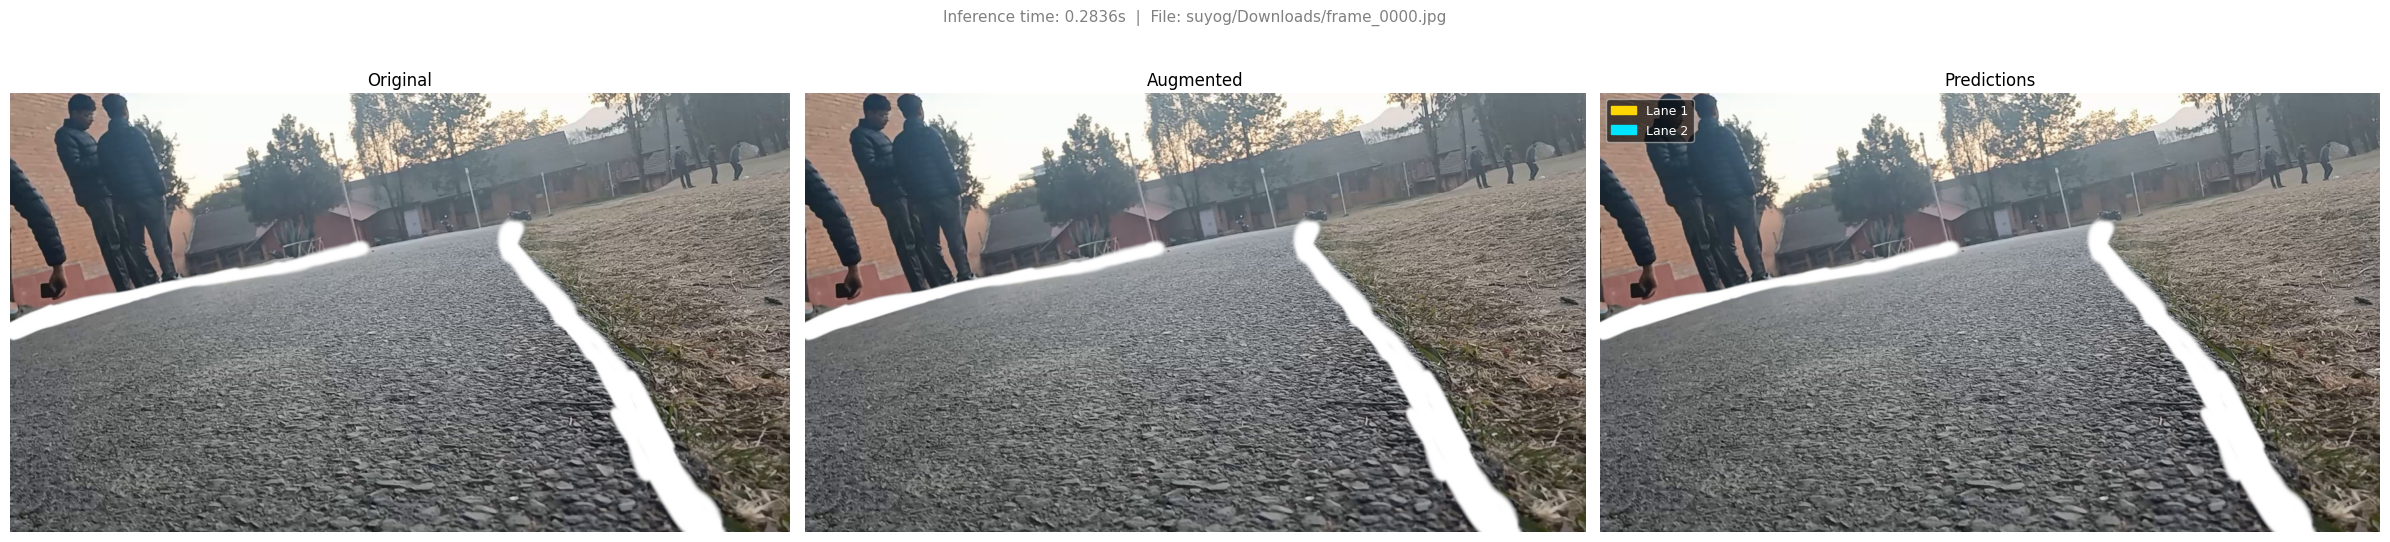

'../results/testing/2026_04_26__10_23_18_pipeline_testing_with_no_augmentation/inference/visualization_0000.png'

In [18]:
experiment.visualize_prediction(ModelOutput, show=True)